In [51]:
import pandas as pd
import matplotlib.pyplot as plt

from utils_io import salvar_df, carregar_df, salvar_grafico

In [5]:
df_episodios_base = carregar_df("blackjack_episodios_etapa_basica", pasta="dados")
df_decisoes_base = carregar_df("blackjack_decisoes_etapa_basica", pasta="dados")
df_resultados_qlearning = carregar_df("blackjack_resultados_qlearning", pasta="dados")
df_treinamento_qlearning = carregar_df("blackjack_treinamento_qlearning", pasta="dados")
df_qtable = carregar_df("blackjack_q_table", pasta="modelos")

Lendo arquivo: C:\Users\Daianne\Documents\blackjack_RL\dados\blackjack_episodios_etapa_basica.csv
Lendo arquivo: C:\Users\Daianne\Documents\blackjack_RL\dados\blackjack_decisoes_etapa_basica.csv
Lendo arquivo: C:\Users\Daianne\Documents\blackjack_RL\dados\blackjack_resultados_qlearning.csv
Lendo arquivo: C:\Users\Daianne\Documents\blackjack_RL\dados\blackjack_treinamento_qlearning.csv
Lendo arquivo: C:\Users\Daianne\Documents\blackjack_RL\modelos\blackjack_q_table.csv


In [6]:
print("Episódios política básica:", df_episodios_base.shape)
print("Decisões política básica:", df_decisoes_base.shape)
print("Resultados qlearning:", df_resultados_qlearning.shape)
print("Treinamento qlearning:", df_treinamento_qlearning.shape)
print("Q-table:", df_qtable.shape)

Episódios política básica: (10000, 10)
Decisões política básica: (13668, 7)
Resultados qlearning: (5000, 10)
Treinamento qlearning: (20000, 7)
Q-table: (280, 6)


In [7]:
colunas_resultados = [
    "id_episodio",
    "politica",
    "resultado",
    "recompensa",
    "total_jogador",
    "total_dealer",
    "dealer_carta_visivel",
    "qtd_passos",
    "mao_jogador",
    "mao_dealer"
]

df_episodios_base = df_episodios_base[colunas_resultados].copy()
df_resultados_qlearning = df_resultados_qlearning[colunas_resultados].copy()

df_resultados = pd.concat(
    [df_episodios_base, df_resultados_qlearning],
    ignore_index=True
)

df_resultados.head()

,id_episodio,politica,resultado,recompensa,total_jogador,total_dealer,dealer_carta_visivel,qtd_passos,mao_jogador,mao_dealer
0,0,aleatoria,vitoria,1,17,26,10,1,"[7, 10]","[10, 5, 1, 10]"
1,1,aleatoria,derrota,-1,13,20,3,1,"[3, 10]","[3, 7, 10]"
2,2,aleatoria,vitoria,1,21,18,5,1,"[1, 10]","[5, 3, 10]"
3,3,aleatoria,vitoria,1,21,20,9,2,"[10, 4, 7]","[9, 2, 3, 6]"
4,4,aleatoria,derrota,-1,27,7,3,1,"[10, 7, 10]","[3, 4]"


In [8]:
df_resultados.groupby("politica")["id_episodio"].count().reset_index(name="qtd_episodios")

,politica,qtd_episodios
0,aleatoria,5000
1,basica,5000
2,qlearning,5000


In [9]:
distribuicao_resultados = (
    df_resultados
    .groupby(["politica", "resultado"])
    .size()
    .reset_index(name="qtd")
)

distribuicao_resultados

,politica,resultado,qtd
0,aleatoria,derrota,3227
1,aleatoria,empate,245
2,aleatoria,vitoria,1528
3,basica,derrota,2383
4,basica,empate,504
5,basica,vitoria,2113
6,qlearning,derrota,2400
7,qlearning,empate,448
8,qlearning,vitoria,2152


Gráfico salvo em: C:\Users\Daianne\Documents\blackjack_RL\graficos\Distribuição de resultados por política.png


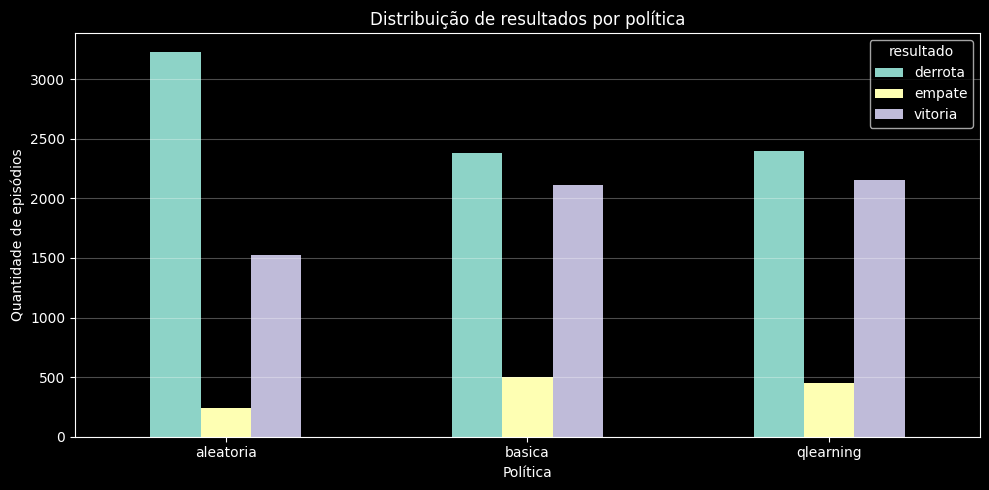

In [37]:
pivot_resultados = distribuicao_resultados.pivot(
    index="politica",
    columns="resultado",
    values="qtd"
).fillna(0)

pivot_resultados.plot(kind="bar", figsize=(10, 5))
plt.title("Distribuição de resultados por política")
plt.xlabel("Política")
plt.ylabel("Quantidade de episódios")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
salvar_grafico("Distribuição de resultados por política.png")
plt.show()

In [11]:
recompensa_media = (
    df_resultados
    .groupby("politica")["recompensa"]
    .mean()
    .reset_index(name="recompensa_media")
)

recompensa_media

,politica,recompensa_media
0,aleatoria,-0.3398
1,basica,-0.0540
2,qlearning,-0.0496


Gráfico salvo em: C:\Users\Daianne\Documents\blackjack_RL\graficos\Recompensa média por política.png


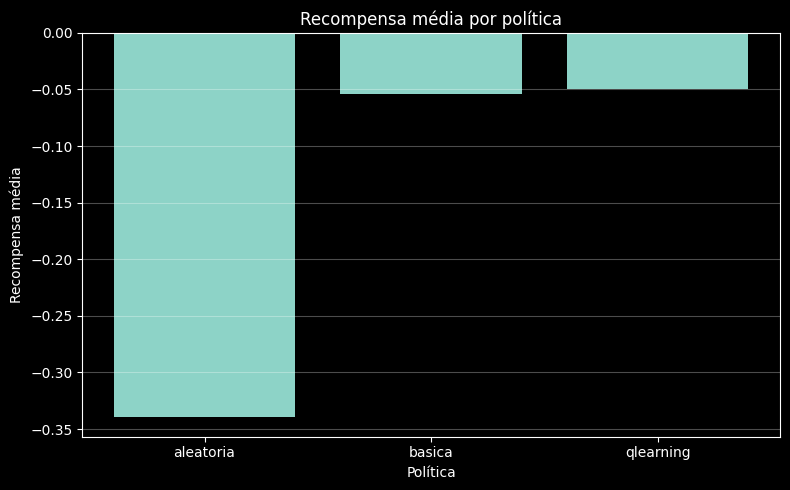

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(recompensa_media["politica"], recompensa_media["recompensa_media"])
plt.title("Recompensa média por política")
plt.xlabel("Política")
plt.ylabel("Recompensa média")
plt.grid(axis="y", alpha=0.3)
salvar_grafico("Recompensa média por política.png")
plt.show()

In [13]:
passos_medios = (
    df_resultados
    .groupby("politica")["qtd_passos"]
    .mean()
    .reset_index(name="passos_medios")
)

passos_medios

,politica,passos_medios
0,aleatoria,1.3378
1,basica,1.6134
2,qlearning,1.5654


Gráfico salvo em: C:\Users\Daianne\Documents\blackjack_RL\graficos\Quantidade média de passos por política.png


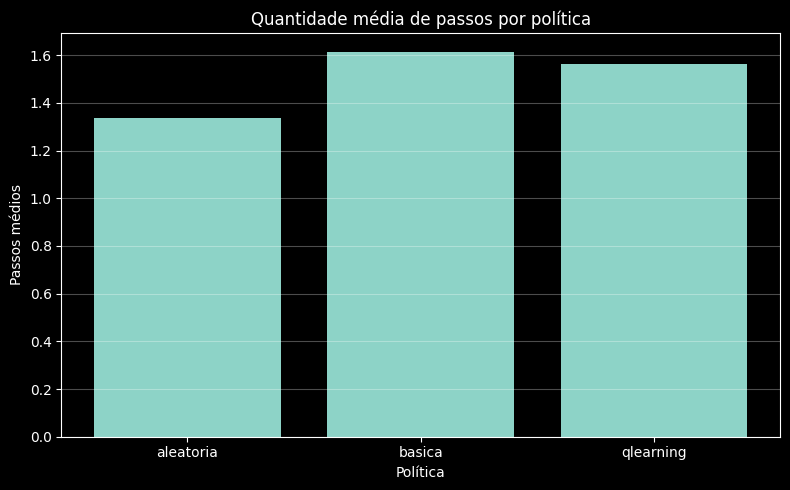

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(passos_medios["politica"], passos_medios["passos_medios"])
plt.title("Quantidade média de passos por política")
plt.xlabel("Política")
plt.ylabel("Passos médios")
plt.grid(axis="y", alpha=0.3)
salvar_grafico("Quantidade média de passos por política.png")
plt.show()

In [40]:
df_resultados["estouro_jogador"] = (df_resultados["total_jogador"] > 21).astype(int)
df_resultados["estouro_dealer"] = (df_resultados["total_dealer"] > 21).astype(int)

taxas_estouro = (
    df_resultados
    .groupby("politica")
    .agg(
        taxa_estouro_jogador=("estouro_jogador", "mean"),
        taxa_estouro_dealer=("estouro_dealer", "mean")
    )
    .reset_index()
)

taxas_estouro

,politica,taxa_estouro_jogador,taxa_estouro_dealer
0,aleatoria,0.2886,0.1970
1,basica,0.2778,0.2112
2,qlearning,0.1904,0.2434


Gráfico salvo em: C:\Users\Daianne\Documents\blackjack_RL\graficos\Taxa de estouro por política.png


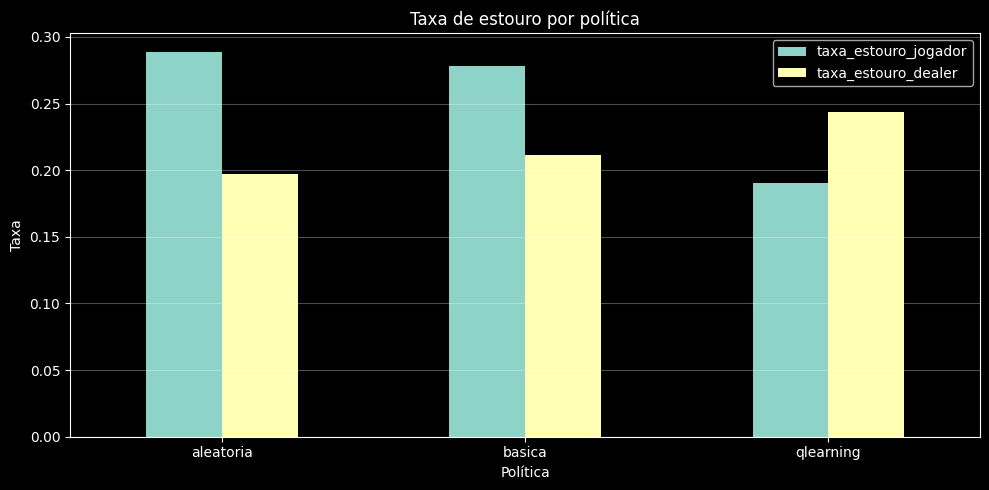

In [41]:
taxas_estouro_plot = taxas_estouro.set_index("politica")
taxas_estouro_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Taxa de estouro por política")
plt.xlabel("Política")
plt.ylabel("Taxa")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
salvar_grafico("Taxa de estouro por política.png")
plt.show()

In [42]:
acoes_por_politica = (
    df_decisoes_base
    .groupby(["politica", "acao"])
    .size()
    .reset_index(name="qtd")
)

acoes_por_politica

,politica,acao,qtd
0,aleatoria,hit,3132
1,aleatoria,stick,3100
2,basica,hit,4456
3,basica,stick,2980


Gráfico salvo em: C:\Users\Daianne\Documents\blackjack_RL\graficos\Distribuição de ações por política.png


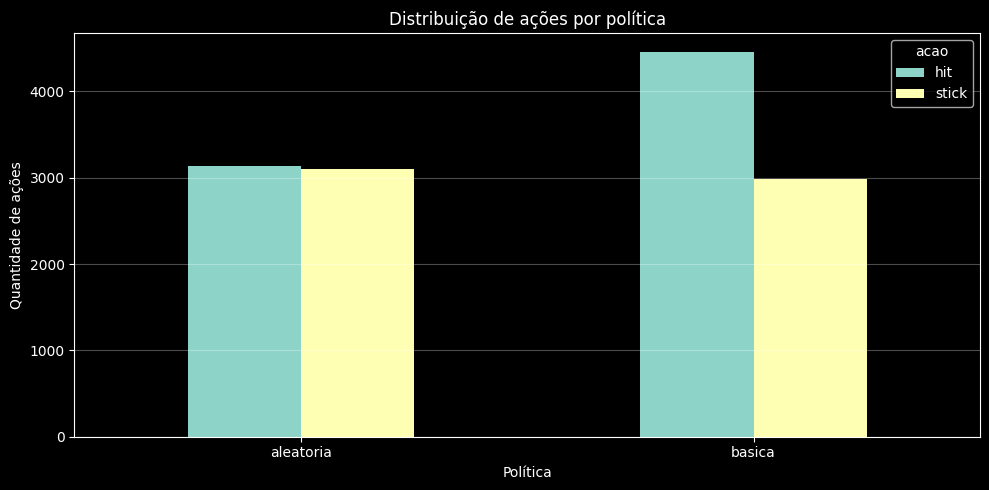

In [44]:
pivot_acoes = acoes_por_politica.pivot(
    index="politica",
    columns="acao",
    values="qtd"
).fillna(0)

pivot_acoes.plot(kind="bar", figsize=(10, 5))
plt.title("Distribuição de ações por política")
plt.xlabel("Política")
plt.ylabel("Quantidade de ações")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
salvar_grafico("Distribuição de ações por política.png")
plt.show()

In [19]:
acoes_por_soma = (
    df_decisoes_base
    .groupby(["politica", "soma_jogador", "acao"])
    .size()
    .reset_index(name="qtd")
)

acoes_por_soma.head(20)

,politica,soma_jogador,acao,qtd
0,aleatoria,4,hit,14
1,aleatoria,4,stick,13
2,aleatoria,5,hit,34
3,aleatoria,5,stick,23
4,aleatoria,6,hit,45
5,aleatoria,6,stick,33
6,aleatoria,7,hit,57
7,aleatoria,7,stick,65
8,aleatoria,8,hit,70
9,aleatoria,8,stick,70


In [20]:
tabela_basica_soma = (
    acoes_por_soma[acoes_por_soma["politica"] == "basica"]
    .pivot_table(
        index="soma_jogador",
        columns="acao",
        values="qtd",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

tabela_basica_soma

acao,soma_jogador,hit,stick
0,4,23,0
1,5,60,0
2,6,95,0
3,7,124,0
4,8,166,0
5,9,203,0
6,10,263,0
7,11,293,0
8,12,573,0
9,13,658,0


Gráfico salvo em: C:\Users\Daianne\Documents\blackjack_RL\graficos\Ações da política básica por soma do jogador.png


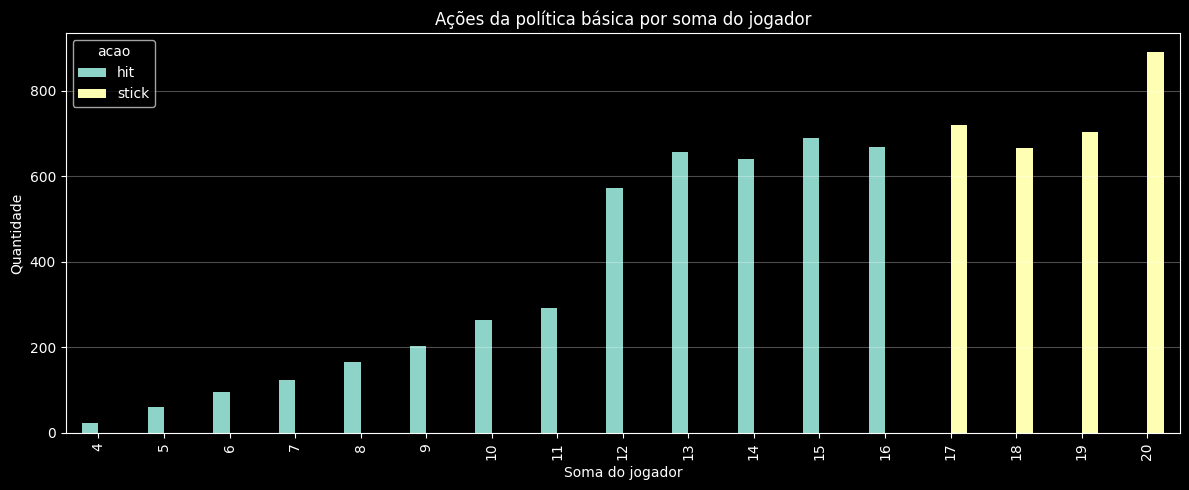

In [45]:
tabela_plot = tabela_basica_soma.set_index("soma_jogador")
tabela_plot.plot(kind="bar", figsize=(12, 5))
plt.title("Ações da política básica por soma do jogador")
plt.xlabel("Soma do jogador")
plt.ylabel("Quantidade")
plt.grid(axis="y", alpha=0.3)
salvar_grafico("Ações da política básica por soma do jogador.png")
plt.show()

In [22]:
df_treinamento_qlearning.head()

,id_episodio,resultado,recompensa_total,qtd_passos,epsilon,mao_jogador_final,mao_dealer_final
0,0,derrota,-1,2,1.000000,"[10, 2, 3, 10]","[1, 10]"
1,1,empate,0,2,0.999500,"[7, 1, 9]","[1, 2, 4]"
2,2,derrota,-1,1,0.999000,"[8, 10, 10]","[5, 10]"
3,3,derrota,-1,1,0.998501,"[7, 6]","[5, 3, 2, 2, 7]"
4,4,derrota,-1,2,0.998001,"[2, 6, 10, 7]","[6, 10]"


In [23]:
bloco = 500

df_treinamento_qlearning = df_treinamento_qlearning.copy()
df_treinamento_qlearning["bloco_episodio"] = df_treinamento_qlearning["id_episodio"] // bloco

evolucao_treinamento = (
    df_treinamento_qlearning
    .groupby("bloco_episodio")
    .agg(
        recompensa_media=("recompensa_total", "mean"),
        passos_medios=("qtd_passos", "mean"),
        epsilon_medio=("epsilon", "mean")
    )
    .reset_index()
)

evolucao_treinamento.head()

,bloco_episodio,recompensa_media,passos_medios,epsilon_medio
0,0,-0.366,1.390,0.884992
1,1,-0.304,1.374,0.689189
2,2,-0.226,1.434,0.536707
3,3,-0.240,1.436,0.417962
4,4,-0.248,1.422,0.325489


Gráfico salvo em: C:\Users\Daianne\Documents\blackjack_RL\graficos\Evolução da recompensa média no treinamento do Q-learning.png


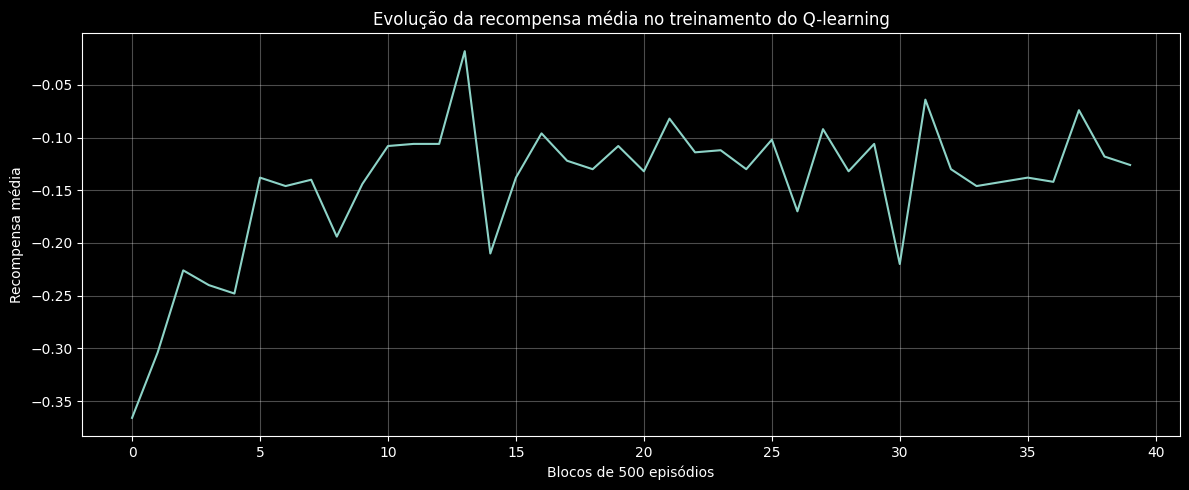

In [46]:
plt.figure(figsize=(12, 5))
plt.plot(evolucao_treinamento["bloco_episodio"], evolucao_treinamento["recompensa_media"])
plt.title("Evolução da recompensa média no treinamento do Q-learning")
plt.xlabel(f"Blocos de {bloco} episódios")
plt.ylabel("Recompensa média")
plt.grid(alpha=0.3)
salvar_grafico("Evolução da recompensa média no treinamento do Q-learning.png")
plt.show()

Gráfico salvo em: C:\Users\Daianne\Documents\blackjack_RL\graficos\Evolução do epsilon no treinamento.png


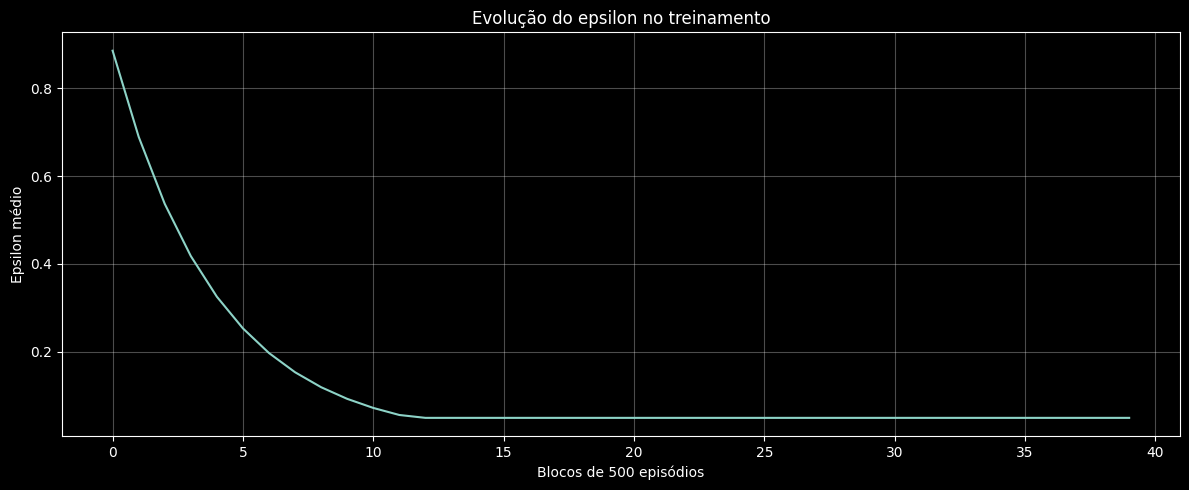

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(evolucao_treinamento["bloco_episodio"], evolucao_treinamento["epsilon_medio"])
plt.title("Evolução do epsilon no treinamento")
plt.xlabel(f"Blocos de {bloco} episódios")
plt.ylabel("Epsilon médio")
plt.grid(alpha=0.3)
salvar_grafico("Evolução do epsilon no treinamento.png")
plt.show()

Gráfico salvo em: C:\Users\Daianne\Documents\blackjack_RL\graficos\Evolução da quantidade média de passos no treinamento.png


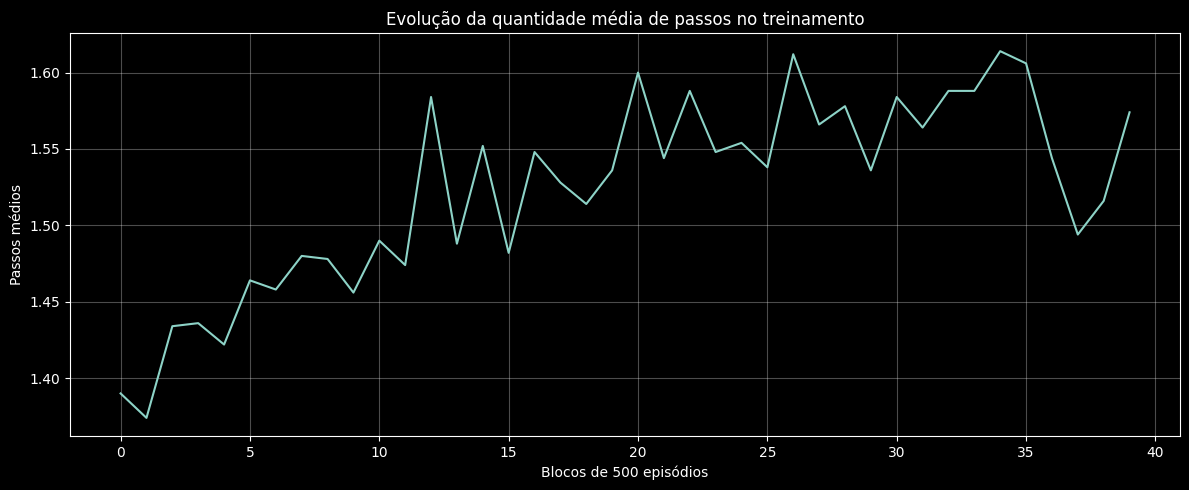

In [48]:
plt.figure(figsize=(12, 5))
plt.plot(evolucao_treinamento["bloco_episodio"], evolucao_treinamento["passos_medios"])
plt.title("Evolução da quantidade média de passos no treinamento")
plt.xlabel(f"Blocos de {bloco} episódios")
plt.ylabel("Passos médios")
plt.grid(alpha=0.3)
salvar_grafico("Evolução da quantidade média de passos no treinamento.png")
plt.show()

In [27]:
df_qtable.head(20)

,soma_jogador,carta_dealer,as_utilizavel,q_hit,q_stick,melhor_acao
0,4,1,0,-0.280786,-0.271000,stick
1,4,2,0,-0.063072,-0.100000,hit
2,4,3,0,-0.070284,-0.271000,hit
3,4,4,0,-0.061236,-0.100000,hit
4,4,5,0,-0.009023,-0.100000,hit
5,4,6,0,0.036668,-0.100000,hit
6,4,7,0,-0.040205,-0.100000,hit
7,4,8,0,-0.018391,-0.100000,hit
8,4,9,0,-0.164974,-0.191539,hit
9,4,10,0,-0.340179,-0.409510,hit


In [28]:
df_qtable["melhor_acao"].value_counts()

melhor_acao
hit      169
stick    111
Name: count, dtype: int64

Gráfico salvo em: C:\Users\Daianne\Documents\blackjack_RL\graficos\Quantidade de estados por melhor ação na Q-table.png


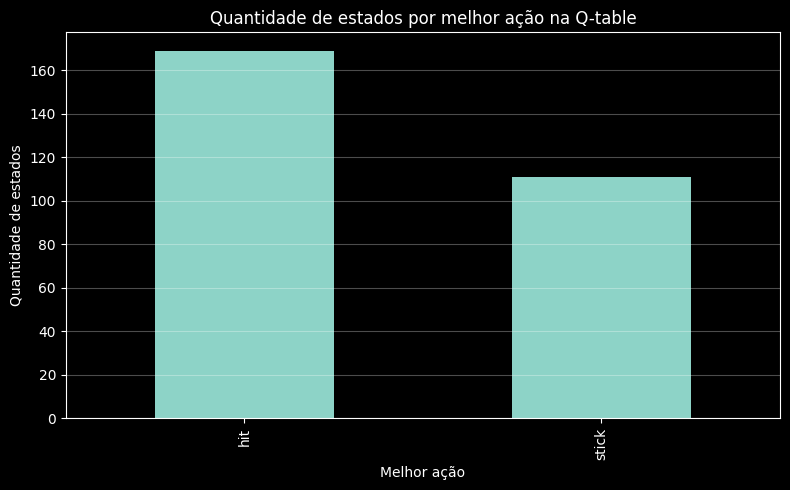

In [49]:
df_qtable["melhor_acao"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Quantidade de estados por melhor ação na Q-table")
plt.xlabel("Melhor ação")
plt.ylabel("Quantidade de estados")
plt.grid(axis="y", alpha=0.3)
salvar_grafico("Quantidade de estados por melhor ação na Q-table.png")
plt.show()

In [30]:
qtable_sem_as = df_qtable[df_qtable["as_utilizavel"] == 0].copy()

mapa_sem_as = qtable_sem_as.pivot_table(
    index="soma_jogador",
    columns="carta_dealer",
    values="melhor_acao",
    aggfunc="first"
)

mapa_sem_as

carta_dealer,1,2,3,4,5,6,7,8,9,10
soma_jogador,,,,,,,,,,
4,stick,hit,hit,hit,hit,hit,hit,hit,hit,hit
5,hit,hit,stick,stick,hit,hit,hit,hit,stick,hit
6,hit,hit,hit,hit,hit,hit,hit,hit,hit,hit
7,hit,hit,hit,hit,hit,hit,stick,hit,stick,hit
8,hit,hit,hit,hit,hit,hit,hit,hit,hit,hit
9,hit,hit,hit,hit,hit,hit,hit,hit,hit,hit
10,hit,hit,hit,stick,hit,hit,hit,hit,hit,hit
11,hit,hit,hit,hit,hit,hit,hit,hit,hit,hit
12,hit,hit,hit,hit,stick,stick,hit,hit,hit,hit


In [31]:
qtable_com_as = df_qtable[df_qtable["as_utilizavel"] == 1].copy()

mapa_com_as = qtable_com_as.pivot_table(
    index="soma_jogador",
    columns="carta_dealer",
    values="melhor_acao",
    aggfunc="first"
)

mapa_com_as

carta_dealer,1,2,3,4,5,6,7,8,9,10
soma_jogador,,,,,,,,,,
12,hit,hit,hit,hit,stick,hit,hit,stick,stick,hit
13,hit,stick,hit,hit,hit,hit,hit,hit,hit,hit
14,stick,hit,hit,hit,hit,hit,hit,hit,hit,hit
15,hit,hit,hit,hit,hit,hit,hit,hit,hit,hit
16,stick,hit,stick,hit,hit,hit,hit,hit,hit,hit
17,hit,hit,hit,hit,hit,hit,hit,hit,hit,hit
18,hit,hit,stick,stick,hit,hit,stick,stick,hit,hit
19,stick,hit,stick,stick,hit,stick,hit,stick,stick,hit
20,stick,stick,stick,stick,stick,stick,stick,stick,stick,stick


In [32]:
resumo_final = (
    df_resultados
    .groupby("politica")
    .agg(
        episodios=("id_episodio", "count"),
        recompensa_media=("recompensa", "mean"),
        passos_medios=("qtd_passos", "mean"),
        total_medio_jogador=("total_jogador", "mean"),
        total_medio_dealer=("total_dealer", "mean")
    )
    .reset_index()
)

resumo_final

,politica,episodios,recompensa_media,passos_medios,total_medio_jogador,total_medio_dealer
0,aleatoria,5000,-0.3398,1.3378,18.3896,18.6306
1,basica,5000,-0.0540,1.6134,20.3196,18.7396
2,qlearning,5000,-0.0496,1.5654,18.9292,19.3342


In [33]:
taxa_vitoria_final = (
    df_resultados
    .assign(vitoria=lambda x: (x["resultado"] == "vitoria").astype(int))
    .groupby("politica")["vitoria"]
    .mean()
    .reset_index(name="taxa_vitoria")
)

taxa_vitoria_final

,politica,taxa_vitoria
0,aleatoria,0.3056
1,basica,0.4226
2,qlearning,0.4304


In [34]:
resumo_final = resumo_final.merge(
    taxa_vitoria_final,
    on="politica",
    how="left"
)

resumo_final = resumo_final.sort_values(
    by=["taxa_vitoria", "recompensa_media"],
    ascending=False
).reset_index(drop=True)

resumo_final

,politica,episodios,recompensa_media,passos_medios,total_medio_jogador,total_medio_dealer,taxa_vitoria
0,qlearning,5000,-0.0496,1.5654,18.9292,19.3342,0.4304
1,basica,5000,-0.0540,1.6134,20.3196,18.7396,0.4226
2,aleatoria,5000,-0.3398,1.3378,18.3896,18.6306,0.3056


Gráfico salvo em: C:\Users\Daianne\Documents\blackjack_RL\graficos\Taxa de vitória por política.png


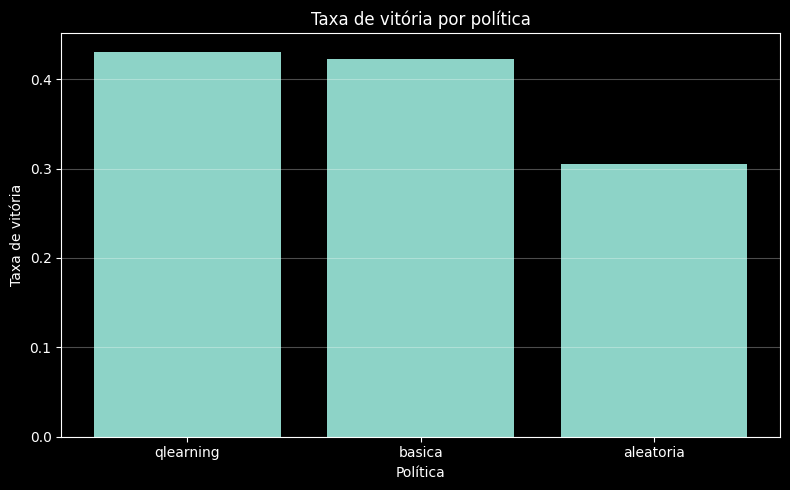

In [50]:
plt.figure(figsize=(8, 5))
plt.bar(resumo_final["politica"], resumo_final["taxa_vitoria"])
plt.title("Taxa de vitória por política")
plt.xlabel("Política")
plt.ylabel("Taxa de vitória")
plt.grid(axis="y", alpha=0.3)
salvar_grafico("Taxa de vitória por política.png")
plt.show()